# **Task 4**

## **DJS Synapse Learning Period**
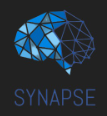

Congratulations on making it this far!! Welcome to the world of classification where we move on from unsupervised to helping the algorithms by telling them exactly what the data we're feeding them is. This week we'll be looking into  many algorithms such as Decision Trees, SVC, Naive Bayes, Random Forest and so on. We'll also be delving into hyperparameter tuning the only place where ched chaad can lead to a good result.

**Warning: This task contains many theory questions. Proceed with caution!**

Jk, make sure you research well and make sure you are understanding the models y'all are implementing as that will make your concepts much stronger and build a strong ML foundation which will be very useful as we move further with the tasks.

### Overfitting and Underfitting [VERY IMPORTANT]:
https://www.youtube.com/watch?v=T9NtOa-IITo
Note : This concept can be seen in K Means and decision trees. In fact, we will look deeper into
this when we begin deep learning.

## Importing the dataset

Use this link to download the adult income dataset and upload it to your drive.

https://drive.google.com/file/d/1VAE1qF16D-sKnBOWXzGXVNGhtNZNLFQS/view?usp=sharing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import matplotlib.pyplot as plt

Mounted at /content/drive


In [ ]:
#import your dataset here
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/adult_income_dataset.csv")

## Dealing with Nan values

In [ ]:
#write a code to find the nan values for the dataset and make a decision on whether to dropna or fill na

nan_values = df.isnull().sum()
print("NaN values per column:")
print(nan_values)



NaN values per column:
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


In [ ]:
# Fill missing values with the mode for each column
for col in ['workclass', 'occupation', 'native-country']:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nNaN values per column after filling:")
print(df.isnull().sum())


NaN values per column after filling:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


/tmp/ipython-input-2802147161.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


## Object Valued Columns

For Relationship, Race and Sex find out the max division average fnlwgt for each unique value.

In [ ]:
#Write your code here
for col in ['relationship', 'race', 'sex']:
    max_avg_fnlwgt = df.groupby(col)['fnlwgt'].mean().max()
    print(f"Maximum average final weight for each unique value in '{col}': {max_avg_fnlwgt}")

Maximum average final weight for each unique value in 'relationship': 205059.82161060142
Maximum average final weight for each unique value in 'race': 228013.1241997439
Maximum average final weight for each unique value in 'sex': 191771.44901330885


## Getting rid of unnecessary columns

*   Drop the education num column since we already have their education in the form of categories
*   Check the combinations of the marital-status and relationship column, see if we need both of them or just marital status will work too.


In [ ]:
#write your code here
df = df.drop('education-num', axis=1)

In [ ]:
#write your code here
combinations = df.groupby(['marital-status', 'relationship']).size().reset_index(name='count')
print("Combinations of Marital Status and Relationship:")
print(combinations)

Combinations of Marital Status and Relationship:
           marital-status    relationship  count
0                Divorced   Not-in-family   2404
1                Divorced  Other-relative    110
2                Divorced       Own-child    328
3                Divorced       Unmarried   1601
4       Married-AF-spouse         Husband      9
5       Married-AF-spouse  Other-relative      1
6       Married-AF-spouse       Own-child      1
7       Married-AF-spouse            Wife     12
8      Married-civ-spouse         Husband  13184
9      Married-civ-spouse   Not-in-family     17
10     Married-civ-spouse  Other-relative    124
11     Married-civ-spouse       Own-child     95
12     Married-civ-spouse            Wife   1556
13  Married-spouse-absent   Not-in-family    211
14  Married-spouse-absent  Other-relative     32
15  Married-spouse-absent       Own-child     45
16  Married-spouse-absent       Unmarried    130
17          Never-married   Not-in-family   4706
18          Never-ma

## Dealing with Categorical Data
As you probably know by now, the ML models dont know how to deal with String or object type data... so your mission shall you choose to accept it (don't really have much of a choice) is to find out which columns to do one hot encoding on and which columns to do Label Encoding on.

**Hint: Since Marital-status has less number of columns (distinct values na), One Hot encode it**

In [ ]:
#Write your code here
#Hint: Check which needs one hot encoding which needs label encoding
#Then perform necessary transformations (Feel free to add more coding cells)

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical columns and their unique value counts:")
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Categorical columns and their unique value counts:
workclass: 8 unique values
education: 16 unique values
marital-status: 7 unique values
occupation: 14 unique values
relationship: 6 unique values
race: 5 unique values
sex: 2 unique values
native-country: 41 unique values
income: 2 unique values


In [ ]:
# Perform one-hot encoding on 'marital-status'
if 'marital-status' in df.columns:
    df = pd.get_dummies(df, columns=['marital-status'], drop_first=True)
    print("'marital-status' column one-hot encoded.")
else:
    print("'marital-status' column not found, likely already encoded.")

# Display the first few rows to show the result
display(df.head())

'marital-status' column one-hot encoded.


,age,workclass,fnlwgt,education,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed
0,39,State-gov,77516,Bachelors,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,False,False,False,True,False,False
1,50,Self-emp-not-inc,83311,Bachelors,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,False,True,False,False,False,False
2,38,Private,215646,HS-grad,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,False,False,False,False,False,False
3,53,Private,234721,11th,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,False,True,False,False,False,False
4,28,Private,338409,Bachelors,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,False,True,False,False,False,False


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding to 'workclass'
df['workclass'] = label_encoder.fit_transform(df['workclass'])

# Display the first few rows to show the result
display(df.head())

,age,workclass,fnlwgt,education,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed
0,39,6,77516,Bachelors,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,False,False,False,True,False,False
1,50,5,83311,Bachelors,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,False,True,False,False,False,False
2,38,3,215646,HS-grad,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,False,False,False,False,False,False
3,53,3,234721,11th,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,False,True,False,False,False,False
4,28,3,338409,Bachelors,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,False,True,False,False,False,False


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for col in ['occupation', 'relationship']:
    df[col] = label_encoder.fit_transform(df[col])

# Display the first few rows to show the result
display(df.head())

,age,workclass,fnlwgt,education,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed
0,39,6,77516,Bachelors,0,1,White,Male,2174,0,40,United-States,<=50K,False,False,False,True,False,False
1,50,5,83311,Bachelors,3,0,White,Male,0,0,13,United-States,<=50K,False,True,False,False,False,False
2,38,3,215646,HS-grad,5,1,White,Male,0,0,40,United-States,<=50K,False,False,False,False,False,False
3,53,3,234721,11th,5,0,Black,Male,0,0,40,United-States,<=50K,False,True,False,False,False,False
4,28,3,338409,Bachelors,9,5,Black,Female,0,0,40,Cuba,<=50K,False,True,False,False,False,False


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for col in ['education', 'race', 'sex', 'native-country']:
    df[col] = label_encoder.fit_transform(df[col])

# Display the first few rows to show the result
display(df.head())

,age,workclass,fnlwgt,education,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed
0,39,6,77516,9,0,1,4,1,2174,0,40,38,<=50K,False,False,False,True,False,False
1,50,5,83311,9,3,0,4,1,0,0,13,38,<=50K,False,True,False,False,False,False
2,38,3,215646,11,5,1,4,1,0,0,40,38,<=50K,False,False,False,False,False,False
3,53,3,234721,1,5,0,2,1,0,0,40,38,<=50K,False,True,False,False,False,False
4,28,3,338409,9,9,5,2,0,0,0,40,4,<=50K,False,True,False,False,False,False


## Altering the Target Column
Modify the Target Column (income) to make sure that all the values which are <=50K are replaced with a 0 and the values >50K are replaced with a 1.

In [ ]:
# Modify the Target Column (income)
df['income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

# Display the first few rows to show the result
display(df.head())

,age,workclass,fnlwgt,education,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed
0,39,6,77516,9,0,1,4,1,2174,0,40,38,0,False,False,False,True,False,False
1,50,5,83311,9,3,0,4,1,0,0,13,38,0,False,True,False,False,False,False
2,38,3,215646,11,5,1,4,1,0,0,40,38,0,False,False,False,False,False,False
3,53,3,234721,1,5,0,2,1,0,0,40,38,0,False,True,False,False,False,False
4,28,3,338409,9,9,5,2,0,0,0,40,4,0,False,True,False,False,False,False


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Identify numerical columns (all columns except the one-hot encoded ones and the target)
# Assuming all remaining columns are numerical after encoding
numerical_cols = X_train.select_dtypes(include=['int64', 'float64', 'uint8']).columns


# Apply the scaler to the training and testing data
X_train_scaled = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled = scaler.transform(X_test[numerical_cols])



**Extract the target column(income) and store it in a seperate variable and remove it from the original dataset. Additionally, do a 70:30 Train Test Split**

In [ ]:
#write your code here
from sklearn.model_selection import train_test_split

# Extract the target column
target = df['income']
features = df.drop('income', axis=1)

# Perform 70:30 Train Test Split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (22792, 18)
Shape of X_test: (9769, 18)
Shape of y_train: (22792,)
Shape of y_test: (9769,)


### Chalo now that we have the preprocessed data we can feed it into the models. Lets start with some basic ones.

# Logistic Regression
*   Theory:https://www.youtube.com/watch?v=yIYKR4sgzI8&list=PLblh5JKOoLUKxzEP5HA2d-Li7IJkHfXSe
*   Implementation: https://www.youtube.com/watch?v=n40hS9tQmcY


Explain the algorithm, its working and its use cases.

In [ ]:
#import the model and apply it to the data
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# The ConvergenceWarning indicates that the model did not converge.
# Scaling the data or increasing max_iter can help. Scaling is generally recommended.
model = LogisticRegression()

# Train the model on the scaled training data
model.fit(X_train_scaled, y_train)

LogisticRegression()

Find the accuracy and confusion matrix for the same and explain what it shows.

In [ ]:
#write your code here
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions on the scaled test data
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Logistic Regression model: {accuracy:.4f}")

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Generate classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

Accuracy of Logistic Regression model: 0.8050

Confusion Matrix:
[[7116  339]
 [1566  748]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.95      0.88      7455
           1       0.69      0.32      0.44      2314

    accuracy                           0.80      9769
   macro avg       0.75      0.64      0.66      9769
weighted avg       0.79      0.80      0.78      9769



### Now that you have printed a confusion matrix and classification report. Let's see what you have understood from it. Write a short paragraph highlighting what you understoood from it below.

Based on the Confusion Matrix and Classification Report, the Logistic Regression model achieved an overall accuracy of about 80.5%. The Confusion Matrix reveals that the model correctly predicted 7116 instances of income <=50K (True Negatives) and 748 instances of income >50K (True Positives). However, it incorrectly predicted 339 instances as >50K (False Positives) and a significant 1566 instances as <=50K when they were actually >50K (False Negatives). The Classification Report highlights this imbalance: while the model performs well for the <=50K class, its recall for the >50K class is low at 0.32, indicating it misses many positive cases. The precision for the >50K class is higher at 0.69, meaning that when it does predict >50K, it is more likely to be correct. The high number of False Negatives is a key takeaway, showing the model struggles to identify individuals with higher incomes.

# Naive Bayes Algorithm

* Theory : https://youtu.be/jS1CKhALUBQ
* Theory:
https://www.analyticsvidhya.com/blog/2021/09/naive-bayes-algorithm-a-complete-guide-for-data-science-enthusiasts/
* Implementation : https://youtu.be/nHIUYwN-5rM

In [ ]:
#import the model from sklearn and apply it to your data
from sklearn.naive_bayes import GaussianNB

# Initialize the Naive Bayes model
nb_model = GaussianNB()

# Train the model on the scaled training data
nb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_nb = nb_model.predict(X_test_scaled)

# Calculate accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy of Naive Bayes model: {accuracy_nb:.4f}")



Accuracy of Naive Bayes model: 0.8004


# Decision Tree Classifier
* Theory : https://youtu.be/7VeUPuFGJHk
* Theory: https://www.analyticsvidhya.com/blog/2021/08/decision-tree-algorithm/
* Implementation : https://youtu.be/HY2DcBhgwm0

In [ ]:
#import the decision tree from sklearn and run it on your data
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

<b>Print the Model Accuracy</b>

In [ ]:
# Make predictions on the test data
y_pred_dt = dt_model.predict(X_test)

# Calculate accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy of Decision Tree Classifier: {accuracy_dt:.4f}")

Accuracy of Decision Tree Classifier: 0.8103


## Explain: What are the differences in the working of Logistic Regression, Naive Bayes and Decision Tree and explain why are the accuracies are different.

Ans:

## Explain: What are the differences in the working of Logistic Regression, Naive Bayes and Decision Tree and explain why are the accuracies are different.

Ans: In simpler terms, Logistic Regression works by finding a straight line to separate data points into classes, which is effective for linearly separable data but less so for complex patterns. Naive Bayes classifies based on the probability of features occurring with each class, assuming features are independent; this simplicity can be fast but may reduce accuracy if features are correlated. Decision Trees use a series of splits based on feature values to create a tree-like structure that can form intricate boundaries, good for complex data but prone to overfitting if the tree becomes too deep. The varying accuracies arise because each model uses distinct strategies to classify, performing better on datasets that align with their underlying mechanisms.

### Mention some real life use cases for each of these three models:

Ans:

**Logistic Regression:**
*   **Spam Detection:** Classifying emails as spam or not spam.
*   **Credit Risk Assessment:** Predicting the probability of a loan applicant defaulting.


**Naive Bayes:**
*   **Text Classification:** Categorizing documents into different topics (e.g., news articles, reviews).
*   **Sentiment Analysis:** Determining the sentiment of a piece of text (e.g., positive, negative, neutral).

**Decision Tree:**
*   **Customer Churn Prediction:** Identifying customers likely to leave a service.
*   **Credit Scoring:** Evaluating the creditworthiness of individuals.


Now that you have your first result, make sure that you play with the hyperparameters to get a better result. Visualize results, try different hyperparameters by using a loop, GET CREATIVE!<br>

Machine learning is an iteritive process. You will have to keep playing with hyperparameters and algorithms. No fixed algorithm will work on a fixed dataset.

Take this up as a challenge. The person with the best accuracy wins the round!

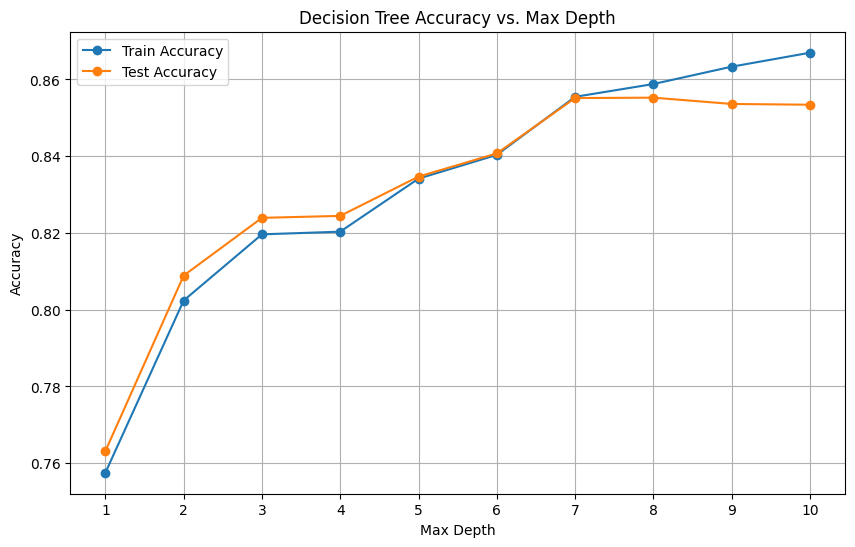

In [ ]:
#plot a graph that shows the train and test accuracy for increasing depth of the tree (do for 10)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

train_accuracies = []
test_accuracies = []
depths = range(1, 11)

for depth in depths:
    # Initialize Decision Tree model with the current depth
    dt_model = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # Train the model
    dt_model.fit(X_train, y_train)

    # Predict on train and test data
    y_train_pred = dt_model.predict(X_train)
    y_test_pred = dt_model.predict(X_test)

    # Calculate accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(depths, test_accuracies, marker='o', label='Test Accuracy')
plt.title('Decision Tree Accuracy vs. Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(depths)
plt.grid(True)
plt.legend()
plt.show()

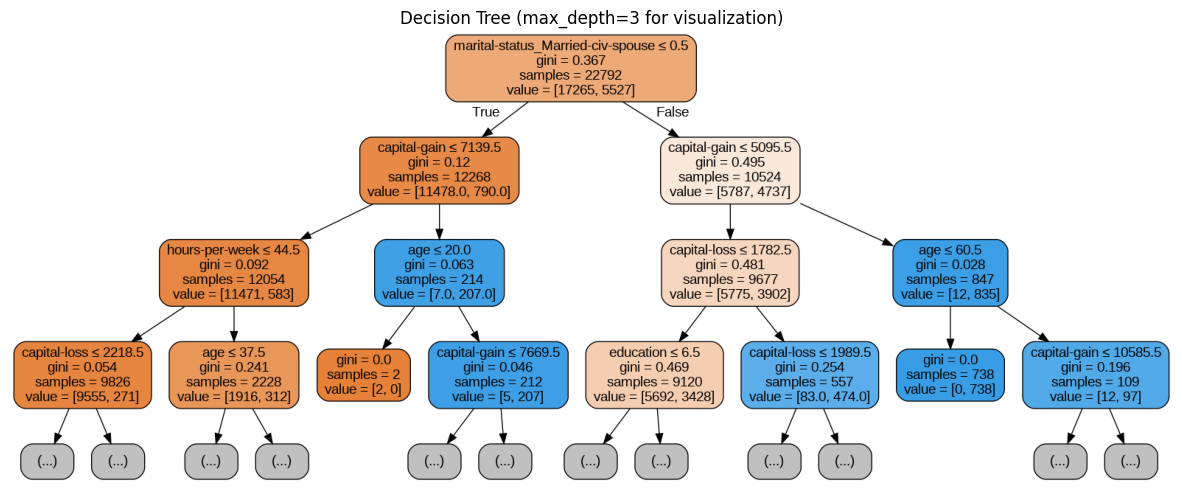

In [ ]:
#complete the code below to create an image of the decision tree
from sklearn import tree
import matplotlib.pyplot as plt

# Ensure graphviz is installed (already in the notebook based on previous execution)
# !pip install graphviz

# Export the decision tree to a dot file
# Using the initial dt_model and limiting max_depth for visualization
tree.export_graphviz(dt_model, out_file='tree.dot', feature_names=X_train.columns,
                     max_depth=3, filled=True, rounded=True, special_characters=True)

# Convert the dot file to a png image
!dot -Tpng tree.dot -o tree.png # to convert the file

# Display the image
try:
    image = plt.imread('tree.png')
    plt.figure(figsize=(15,15))
    plt.imshow(image)
    plt.axis('off') # Hide axes
    plt.title('Decision Tree (max_depth=3 for visualization)')
    plt.show()
except FileNotFoundError:
    print("Error: tree.png not found. Make sure Graphviz is installed and the dot command ran successfully.")

<b>print the test accuracy and train accuracy here</b>

In [ ]:
#write code here


### Explain the different hyperparameters you changed and how did it affect the models. Also give a summary of the graphs you made.

Ans:

## SUPPORT VECTOR MACHINE (SVM)

Theory : https://www.youtube.com/watch?v=efR1C6CvhmE (Part 1)

Theory: https://www.youtube.com/watch?v=H9yACitf-KM

Maths Intuition : https://www.youtube.com/watch?v=Js3GLb1xPhc

EXTRAS:

https://www.youtube.com/watch?v=NDqACjz5j8g

If you are more curious and want to explore :

https://www.youtube.com/watch?v=Toet3EiSFcM (Part 2)

https://www.youtube.com/watch?v=efR1C6CvhmE&t=432s (Part 3)

https://www.youtube.com/watch?v=8bFKyb77vp0




In [ ]:
#Now that we know SVM is sensitive to feature scales, so standardize (don't forget to standardise your X_test):
from sklearn.preprocessing import StandardScaler
numerical_cols = X_train.columns

# Apply the scaler to the training and testing data
X_train_scaled = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled = scaler.transform(X_test[numerical_cols])

print("Features standardized.")

Features standardized.


In [ ]:
#Train your model
from sklearn.svm import SVC

# Initialize the Support Vector Classifier model
svm_model = SVC(random_state=42)

# Train the model on the scaled training data
svm_model.fit(X_train_scaled, y_train)

print("SVM model trained.")

SVM model trained.


In [ ]:
#Predict and check accuracies
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the scaled test data
y_pred_svm = svm_model.predict(X_test_scaled)

# Calculate and print accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy of SVM model: {accuracy_svm:.4f}")

# Optional: Print confusion matrix and classification report
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Accuracy of SVM model: 0.8265

Confusion Matrix:
[[7121  334]
 [1361  953]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.96      0.89      7455
           1       0.74      0.41      0.53      2314

    accuracy                           0.83      9769
   macro avg       0.79      0.68      0.71      9769
weighted avg       0.82      0.83      0.81      9769



In [ ]:
#let's try out using different kernels now. Freedom to choose lies in your hands. EXPLOREEE!

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Let's try an SVM with a radial basis function (RBF) kernel
svm_rbf_model = SVC(kernel='rbf', random_state=42)

# Train the model on the scaled training data
svm_rbf_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_svm_rbf = svm_rbf_model.predict(X_test_scaled)

# Calculate and print accuracy
accuracy_svm_rbf = accuracy_score(y_test, y_pred_svm_rbf)
print(f"Accuracy of SVM model with RBF kernel: {accuracy_svm_rbf:.4f}")



Accuracy of SVM model with RBF kernel: 0.8265


## BIAS AND VARIANCE
### Hurrayy! You have made it so far sane.

### Before moving forward let's first understand what exactly do you mean by bias and variance.

THEORY: https://www.geeksforgeeks.org/machine-learning/bias-vs-variance-in-machine-learning/ (explained in quite detail do read this not just video)

VIDEO: https://www.youtube.com/watch?v=EuBBz3bI-aA


## Optimizing Methods

We can even use Ensemble Methods like **bagging (random forest)**, **boosting (adaboost)** and **Pruning** to improve your accuracy. Again creating a loop of hyperparameters and then finding the best among them is a daunting task. To reduce the efforts, we can use a special technique known as **GridSearchCV**. It finds the best hyperparameters for your model without you having to write multiple loops and evaluating them.

1. GridSearchCV for Random Forest Classifier: https://youtu.be/c4mS7KaOIGY
2. GridSearchCV for Adaboost Classifier: https://youtu.be/JmXnztjULnQ

### 1. Bagging

* Theory : https://www.youtube.com/watch?v=KIOeZ5cFZ50
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
* Implementation : https://www.youtube.com/watch?v=MxiktOPmhV8&t=2s

In [ ]:
#implement Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize the RandomForestClassifier
# Using default hyperparameters for now
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)



In [ ]:
#find the accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest model: {accuracy_rf:.4f}")

Accuracy of Random Forest model: 0.8566


### Explain the difference between random forest and decision tree. Also think of cases where the outputs for both of them can be same if its possible.

Ans :
A Decision Tree is a single model that splits data step by step to make predictions, kind of like following a flowchart. A Random Forest, on the other hand, builds many different decision trees on random parts of the data and then combines their results (usually by voting) to make a final prediction. This makes random forests more accurate and less likely to overfit than a single tree. However, if a random forest has only one tree or if all trees get identical data and features, its output can be the same as a decision tree.

In [ ]:
#write a code to implement BaggingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize the base estimator (e.g., Decision Tree)
base_estimator = DecisionTreeClassifier(random_state=42)

# Initialize the BaggingClassifier
bagging_model = BaggingClassifier(estimator=base_estimator, random_state=42)

# Train the Bagging model
bagging_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_bagging = bagging_model.predict(X_test)

# Evaluate the model's performance
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
print(f"Accuracy of Bagging Classifier: {accuracy_bagging:.4f}")



Accuracy of Bagging Classifier: 0.8469


### Explain how are Bagging and Random Forest different and why do we do bagging?


Ans :Bagging (Bootstrap Aggregating) is a method where we train many models of the same type on different random samples of the data and then combine their predictions to reduce errors and overfitting. A Random Forest is a special case of bagging that uses Decision Trees but adds an extra twist — it also picks random subsets of features for each split, making the trees even more different from each other. We do bagging to make models more stable and accurate by reducing the effect of noise or overfitting in any single model

### 2. Boosting

* Theory : https://www.youtube.com/watch?v=NLRO1-jp5F8&t=724s
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html
*   Theory:https://www.geeksforgeeks.org/ml-xgboost-extreme-gradient-boosting/
* Implementation : https://www.youtube.com/watch?v=7xHM93WXOu8

In [ ]:
#write code here

from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# Initialize the AdaBoost Classifier
adaboost_model = AdaBoostClassifier(random_state=42)

# Train the AdaBoost model
adaboost_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_adaboost = adaboost_model.predict(X_test)

# Evaluate the model's performance
accuracy_adaboost = accuracy_score(y_test, y_pred_adaboost)
print(f"Accuracy of AdaBoost Classifier: {accuracy_adaboost:.4f}")

#yk the drill now

Accuracy of AdaBoost Classifier: 0.8481


Just to make things more interesting implement XGBoost as well and compare its accuracy with that of AdaBoost :)

In [ ]:
!pip install xgboost
import xgboost as xgb


In [ ]:
# Implement XGBoost
import xgboost as xgb
from sklearn.metrics import accuracy_score

# Initialize the XGBoost Classifier
# Use the Scikit-learn API for easier integration
xgb_model = xgb.XGBClassifier(random_state=42)

# Train the XGBoost model
xgb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model's performance
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy of XGBoost Classifier: {accuracy_xgb:.4f}")

Accuracy of XGBoost Classifier: 0.8678


### Explain: What is the difference between Adaboost and XGBoost. Also describe in what cases is XGBoost better to use than AdaBoost.

Ans :Both AdaBoost and XGBoost are boosting algorithms — they build a strong model by combining many weak models (usually decision trees). But they work a bit differently.

AdaBoost (Adaptive Boosting) improves the model by giving more weight to the mistakes made by previous trees. So, each new tree focuses on correcting the errors of the earlier ones. It’s simple and works well on clean, small datasets, but it can be sensitive to noise (wrong or messy data).

XGBoost (Extreme Gradient Boosting) is a more advanced and faster version of boosting. It uses a technique called gradient boosting, which improves the model by reducing the overall error in a smarter, mathematical way. XGBoost also includes regularization (a method to avoid overfitting), supports parallel processing (runs faster), and handles missing data automatically.

When to use XGBoost:
XGBoost is better when you have large datasets, complex patterns, or noisy data because it is faster, more accurate, and more robust than AdaBoost. AdaBoost, on the other hand, is simpler and good for small or less complex problems where speed and heavy computation are not critical.

## Explain: What is the difference between Bagging and Boosting? Explain with examples

Ans:Bagging (Bootstrap Aggregating) trains many models independently on different random samples of the data. Each model gives its prediction, and the final result is usually the average (for regression) or majority vote (for classification). Bagging helps to reduce variance and avoid overfitting. Example: Random Forest is a common example of Bagging — it builds many decision trees on random data samples and then combines their outputs.

Boosting, on the other hand, trains models sequentially, meaning each new model tries to fix the mistakes made by the previous ones. It focuses more on the difficult-to-predict data points. Boosting helps to reduce both bias and variance, making it very powerful but sometimes more sensitive to noisy data.
Example: AdaBoost and XGBoost are examples of Boosting — they build one tree after another, improving the model each time.

In short:

Bagging = many models trained independently → reduces overfitting.

Boosting = models trained one after another → improves accuracy by fixing error








### 3. Pruning Techniques



*   Theory: https://opendatascience.com/what-is-pruning-in-machine-learning/
*   Theory:https://towardsdatascience.com/build-better-decision-trees-with-pruning-8f467e73b107



In [ ]:
#implement pruning
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# We need to find the effective alphas and the corresponding impurities.
path = dt_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Now let's train a decision tree for each alpha and evaluate its performance
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# Evaluate the accuracy for each tree on the test set
test_scores = [accuracy_score(y_test, clf.predict(X_test)) for clf in clfs]

# Find the alpha that gives the maximum accuracy on the test set
optimal_alpha_index = test_scores.index(max(test_scores))
optimal_ccp_alpha = ccp_alphas[optimal_alpha_index]

print(f"Optimal ccp_alpha: {optimal_ccp_alpha:.4f}")
print(f"Maximum test accuracy with optimal ccp_alpha: {max(test_scores):.4f}")

# You can now train a Decision Tree with the optimal_ccp_alpha for the final model
pruned_dt_model = DecisionTreeClassifier(random_state=42, ccp_alpha=optimal_ccp_alpha)
pruned_dt_model.fit(X_train, y_train)

print("\nPruned Decision Tree model trained with optimal ccp_alpha.")

Optimal ccp_alpha: 0.0001
Maximum test accuracy with optimal ccp_alpha: 0.8626

Pruned Decision Tree model trained with optimal ccp_alpha.


In [ ]:
#before plotting a tree you will need to first convert your X_train and X_test to DataFrame (Explain WHY (Hint: You made one tree before and it worked fine so it has to do with something you did after..Explore))
#Code to convert it here:

# Check if X_train and X_test are already DataFrames
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=features.columns)
    print("X_train converted to DataFrame.")
else:
    print("X_train is already a DataFrame.")

if not isinstance(X_test, pd.DataFrame):
    X_test = pd.DataFrame(X_test, columns=features.columns)
    print("X_test converted to DataFrame.")
else:
    print("X_test is already a DataFrame.")

# Explanation for why conversion might be needed:
# When we scaled the data using StandardScaler, X_train and X_test were converted to NumPy arrays.
# The tree plotting function `export_graphviz` can use the `feature_names` parameter to label the features in the plot,
# which makes the tree more interpretable. This parameter works best when the input data has column names,
# which DataFrames provide. The previous tree plotting might have failed or produced a less informative plot without feature names
# if the data was in a NumPy array format at that point.

X_train is already a DataFrame.
X_test is already a DataFrame.


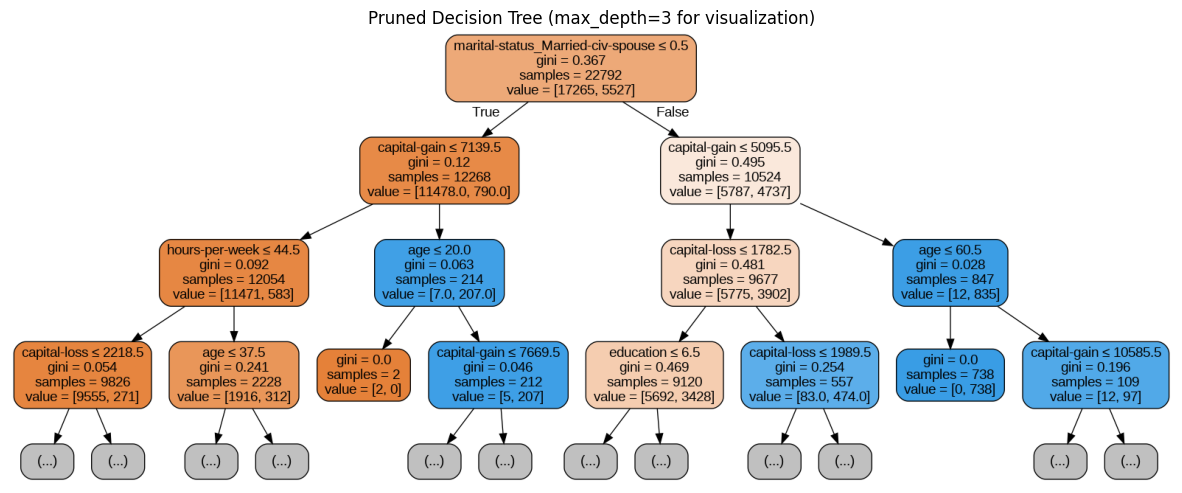

In [ ]:
#plot a tree (image) similar to one created for decision tree (graphwiz) for the pruning technique
from sklearn import tree
import matplotlib.pyplot as plt

# Ensure graphviz is installed (already in the notebook based on previous execution)
# !pip install graphviz

# Export the pruned decision tree to a dot file
tree.export_graphviz(pruned_dt_model, out_file='pruned_tree.dot', feature_names=X_train.columns,
                     filled=True, rounded=True, special_characters=True, max_depth=3) # Limiting depth for readability

# Convert the dot file to a png image
!dot -Tpng pruned_tree.dot -o pruned_tree.png

# Display the image
try:
    image = plt.imread('pruned_tree.png')
    plt.figure(figsize=(15, 15))
    plt.imshow(image)
    plt.axis('off') # Hide axes
    plt.title('Pruned Decision Tree (max_depth=3 for visualization)')
    plt.show()
except FileNotFoundError:
    print("Error: pruned_tree.png not found. Make sure Graphviz is installed and the dot command ran successfully.")

<b>Note that the accuracy on the test set will be considered and brownie points for *not* overfitting the model in the process</b>

As a brush up on data visualisation... make a graph to compare the accuracies you achieved for each of the models you trained and explain which one is the best to perform classification tasks and why?

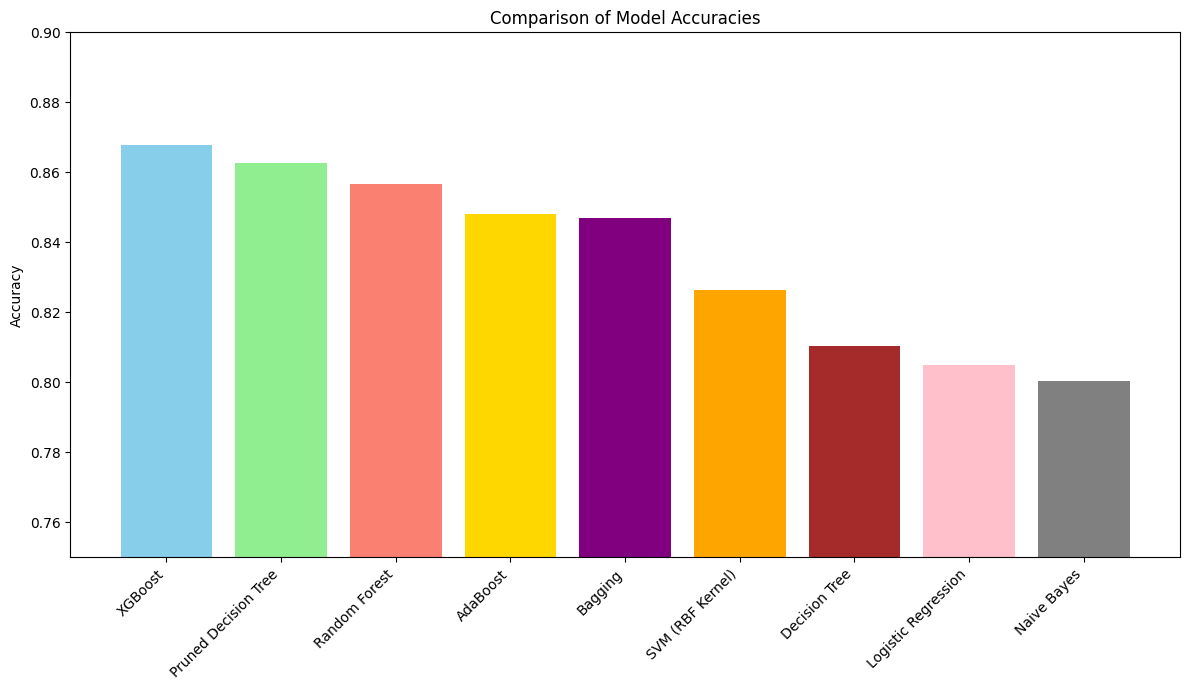

In [ ]:
#write your code here
import matplotlib.pyplot as plt

# Create a dictionary to store accuracies
model_accuracies = {
    'Logistic Regression': accuracy,
    'Naive Bayes': accuracy_nb,
    'Decision Tree': accuracy_dt,
    'SVM (RBF Kernel)': accuracy_svm_rbf,
    'Random Forest': accuracy_rf,
    'Bagging': accuracy_bagging,
    'AdaBoost': accuracy_adaboost,
    'XGBoost': accuracy_xgb,
    'Pruned Decision Tree': max(test_scores) # Using the max test accuracy found during pruning
}

# Sort the models by accuracy for better visualization
sorted_models = sorted(model_accuracies.items(), key=lambda item: item[1], reverse=True)
model_names = [item[0] for item in sorted_models]
accuracies = [item[1] for item in sorted_models]

# Create the bar plot
plt.figure(figsize=(12, 7))
plt.bar(model_names, accuracies, color=['skyblue', 'lightgreen', 'salmon', 'gold', 'purple', 'orange', 'brown', 'pink', 'gray'])
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracies')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.75, 0.9) # Set a reasonable y-limit for better comparison
plt.tight_layout()
plt.show()

# **RESEARCH TASK**

Ensemble Models are not only used for classification but also for Regression.Research on the various regression models such as XGBoost Regressor and Random Forest regressor and how are they different from the Linear Regression model we made in Task 2. The best research will be edited and featured on the Synapse Instagram page. Happy coding! :)

# **End of Task**

> ©DJS Synapse 2025 - 2026